<a href="https://colab.research.google.com/github/qaadhare-tip/CPE-018-CPE31S2---Emerging-Technologies-1-in-CpE/blob/main/CPE018_MidtermExam_(HARE).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPE018 Midterm Exam (2025-2026)


Student Submission Details:
* Name: Hare, Andrei Angelo D.
* Section:  CPE31S2
* Schedule: 4:30 - 7:30 P.M
* Instructor: Engr. Maria Rizette H. Sayo

---

## Intended Learning Outcomes

By the end of this activity, the student should be able to:
* ILO1: Demonstrate different methods for feature matching and detection learned in class and indepdentently from new sources.
* ILO2: Evaluate the accuracy of different feature matching and detection methods and scrutinize its applicability in solving a given real-life problem.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

## Tasks

For this examination, you must create a **mood detection** program with an object-oriented programming approach (same as project CAMEO), it must detect mood changes through the use of algorithms/techniques/schemes learned in class, and from external sources.

In this file, you have to include for each section of your solution your completion of the following:

* Part 1: **Face Detection**: Once your face is detected using any algorithm, it must draw an ROI. The color for the ROI is your choice; however, it must detect for all faces in the frame and draw a corresponding ROI.
* Part 2: **Face Recognition**: The detected face must then be recognized, using any of the provided tools in class, the ROIs must indicate whether it is your face or someone it doesn't recognize.
* Part 3: **Mood Detection**: Use three different feature detection and matching techniques to determine three emotion: happy, sad and neutral. Two of the techniques must be learned from class, and 1 must be one you independently learned.

Properly show through your notebook the output for each part of the exam.

---

## Procedure and Outputs

Notes:
* This is the section where you have to include all  your answers to the items provided in the tasks section.
* Tasks 1 and 2 contribute directly to ILO1: Demonstrate different methods for feature matching and detection learned in class and indepdentently from new sources.
* Task 3 contributes directly to ILO2: Evaluate the accuracy of different feature matching and detection methods and scrutinize its applicability in solving a given real-life problem.

### Task 1: Face Detection

In [14]:
# Include your code here

import cv2
from google.colab.patches import cv2_imshow

picPath = '/content/haretest1.jpg'
haarPath = '/content/haarcascade_frontalface_default(1).xml'

def faceDetect(picPath):
  face_cascade = cv2.CascadeClassifier(haarPath)

  img = cv2.imread(picPath)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.3, 5)

  for (x, y, w, h) in faces:
    img = cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 2)

  cv2_imshow(img)

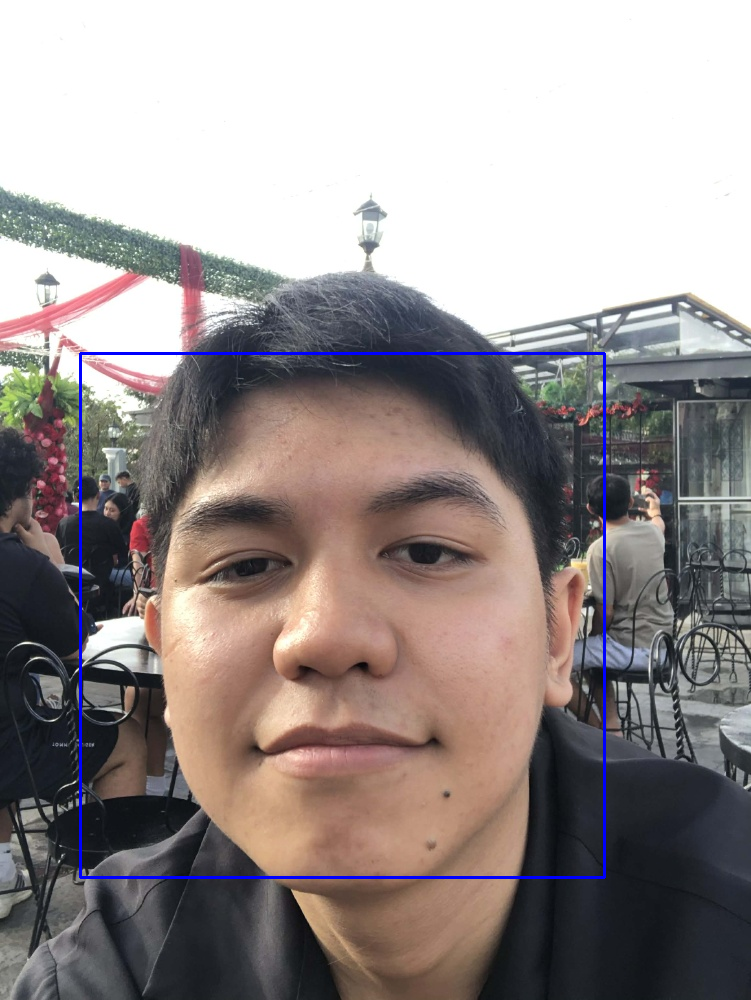

In [15]:
faceDetect(picPath)

### Task 2: Face Recognition

In [44]:
import cv2
import numpy as np
import os

dataset_path = '/content/haredataset'
haarPath = '/content/haarcascade_frontalface_default(1).xml'

face_cascade = cv2.CascadeClassifier(haarPath)
recognizer = cv2.face.LBPHFaceRecognizer_create()

faces = []
ids = []

for image_name in os.listdir(dataset_path):

    if not image_name.endswith('.jpg') or len(image_name.split('.')) < 2:
        print(f"Skipping non-image or malformed file: {image_name}")
        continue


    parts = image_name.split('.')

    if not parts[1].isdigit():
        print(f"Skipping file: {image_name} - invalid ID format (part after first dot is not a digit).")
        continue

    id = int(parts[1])

    img_path = os.path.join(dataset_path, image_name)

    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not load image {img_path}. Skipping.")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    detected_faces = face_cascade.detectMultiScale(gray)

    for (x,y,w,h) in detected_faces:
        faces.append(gray[y:y+h, x:x+w])
        ids.append(id)


if len(faces) > 0 and len(ids) > 0:
    recognizer.train(faces, np.array(ids))
    recognizer.save('/content/face_trainer.yml')
    print("face_trainer.yml created")
else:
    print("No faces found or dataset is empty/invalid. face_trainer.yml was not created.")

Skipping non-image or malformed file: hare1.5.jpeg
Skipping non-image or malformed file: hare1.4.jpeg
Skipping non-image or malformed file: hare1.7.jpeg
Skipping non-image or malformed file: hare1.6.jpeg
face_trainer.yml created


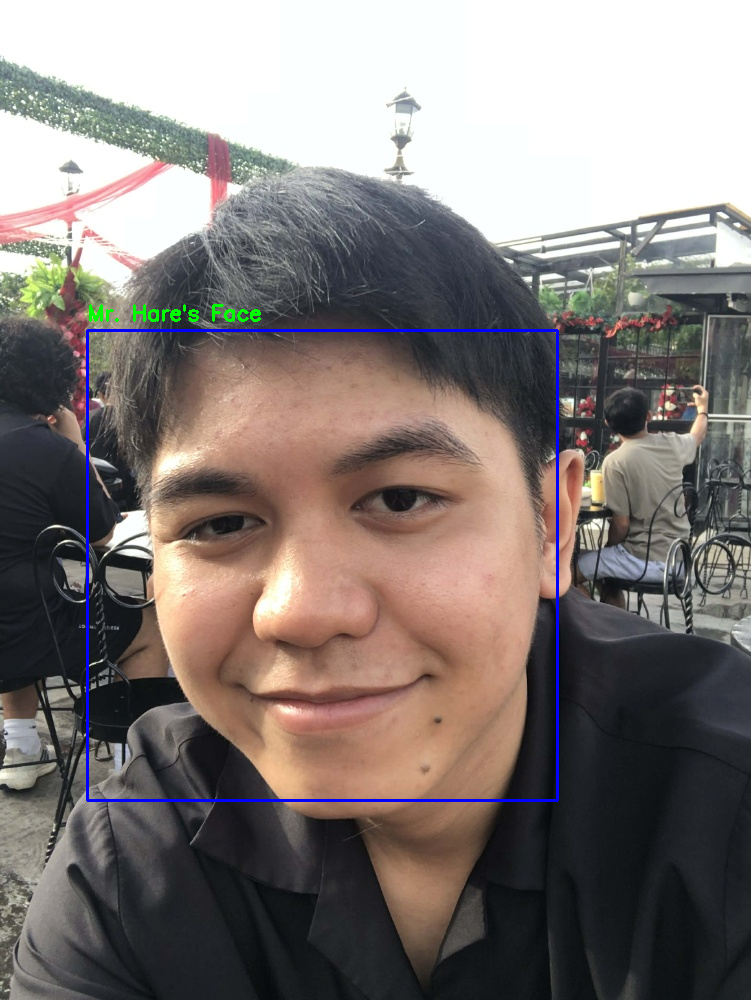

In [60]:
import numpy as np

picPath = '/content/haredataset/hare1.2.jpg'
haarPath = '/content/haarcascade_frontalface_default(1).xml'
modelPath = '/content/face_trainer.yml'

def faceRecognize(picPath):

    face_cascade = cv2.CascadeClassifier(haarPath)

    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.read(modelPath)

    img = cv2.imread(picPath)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:

        roi_gray = gray[y:y+h, x:x+w]

        id, confidence = recognizer.predict(roi_gray)

        if confidence < 70:
            label = "Mr. Hare's Face"
        else:
            label = "You can't see me"

        cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
        cv2.putText(img, label, (x,y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,(0,255,0),2)

    cv2_imshow(img)

faceRecognize(picPath)

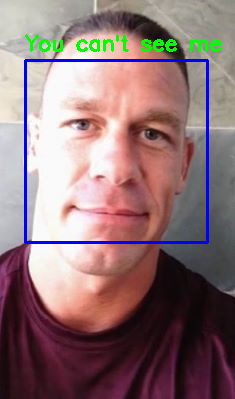

In [57]:
import numpy as np

picPath = '/content/johncena.jpg'
haarPath = '/content/haarcascade_frontalface_default(1).xml'
modelPath = '/content/face_trainer.yml'

def faceRecognize(picPath):

    face_cascade = cv2.CascadeClassifier(haarPath)

    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.read(modelPath)

    img = cv2.imread(picPath)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:

        roi_gray = gray[y:y+h, x:x+w]

        id, confidence = recognizer.predict(roi_gray)

        if confidence < 70:
            label = "Hare's Face"
        else:
            label = "You can't see me"

        cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
        cv2.putText(img, label, (x,y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,(0,255,0),2)

    cv2_imshow(img)

faceRecognize(picPath)

### Task 3: Mood Detection

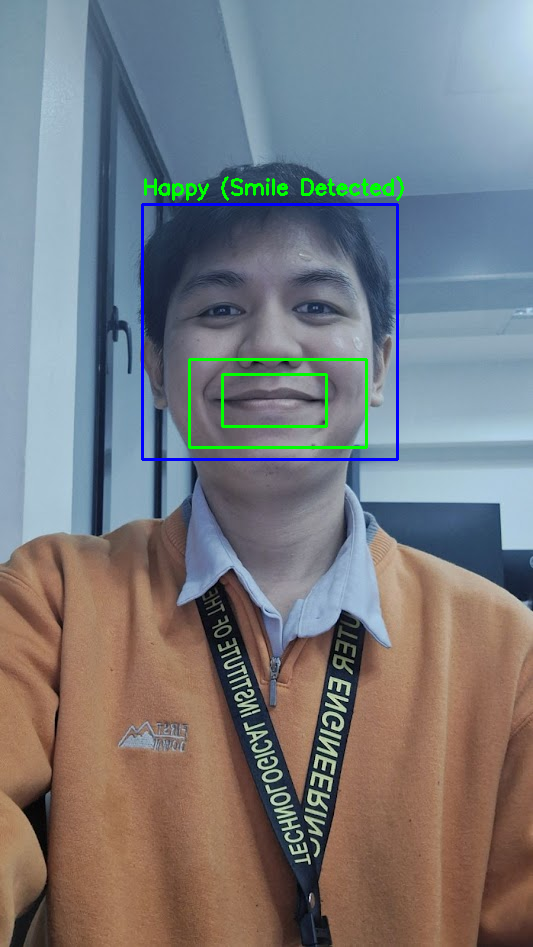

In [41]:
# Technique 1

import cv2
from google.colab.patches import cv2_imshow

picPath = '/content/haretest7(smile).jpeg'
haarPath_face = '/content/haarcascade_frontalface_default(1).xml'
haarPath_smile = '/content/haarcascade_smile(1).xml'

def detect_happy(image_path):
  face_cascade = cv2.CascadeClassifier(haarPath_face)
  smile_cascade = cv2.CascadeClassifier(haarPath_smile)

  img = cv2.imread(image_path)
  if img is None:
      print(f"Error: Unable to load image at {image_path}")
      return

  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


  faces = face_cascade.detectMultiScale(gray, 1.3, 5)

  for (x, y, w, h) in faces:

    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]


    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.7,
        minNeighbors=22,
        minSize=(25, 25),
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    if len(smiles) > 0:
      cv2.putText(img, 'Happy (Smile Detected)', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
      for (sx, sy, sw, sh) in smiles:
          cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 255, 0), 2)
    else:
      cv2.putText(img, 'Neutral/Sad', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

  cv2_imshow(img)


detect_happy(picPath)


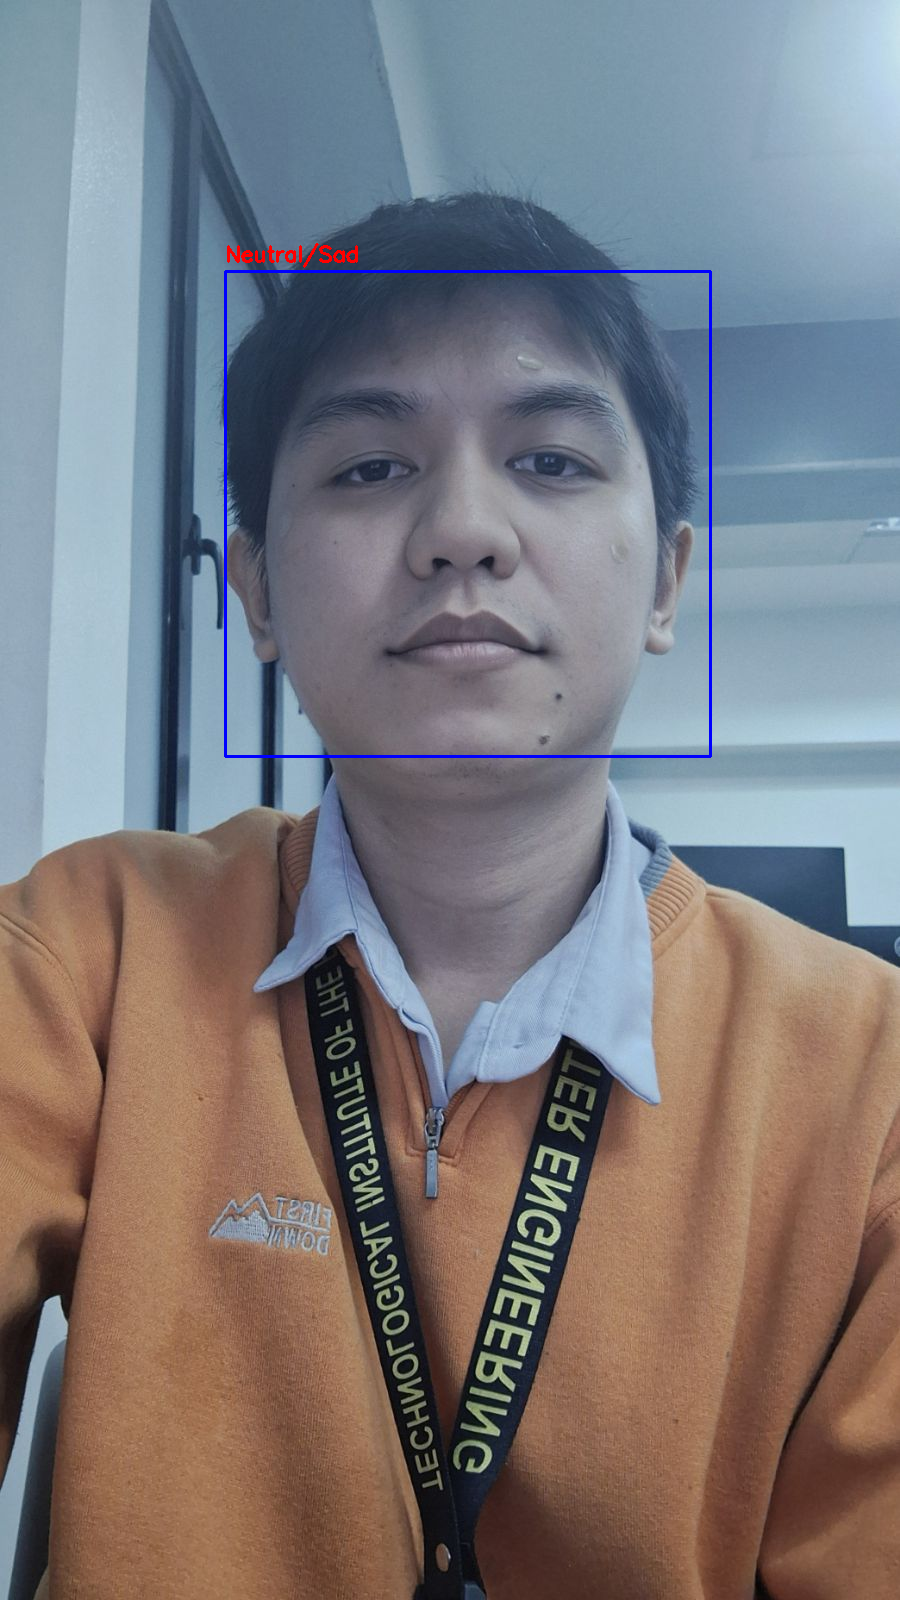

In [38]:
# Technique 2

import cv2
from google.colab.patches import cv2_imshow

picPath = '/content/haretest4(neutral).jpeg'
haarPath_face = '/content/haarcascade_frontalface_default(1).xml'
haarPath_smile = '/content/haarcascade_smile(1).xml'

def detect_happy(image_path):
  face_cascade = cv2.CascadeClassifier(haarPath_face)
  smile_cascade = cv2.CascadeClassifier(haarPath_smile)

  img = cv2.imread(image_path)
  if img is None:
      print(f"Error: Unable to load image at {image_path}")
      return

  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


  faces = face_cascade.detectMultiScale(gray, 1.3, 5)

  for (x, y, w, h) in faces:

    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]


    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.7,
        minNeighbors=22,
        minSize=(25, 25),
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    if len(smiles) > 0:
      cv2.putText(img, 'Happy (Smile Detected)', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
      for (sx, sy, sw, sh) in smiles:
          cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 255, 0), 2)
    else:
      cv2.putText(img, 'Neutral/Sad', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

  cv2_imshow(img)


detect_happy(picPath)

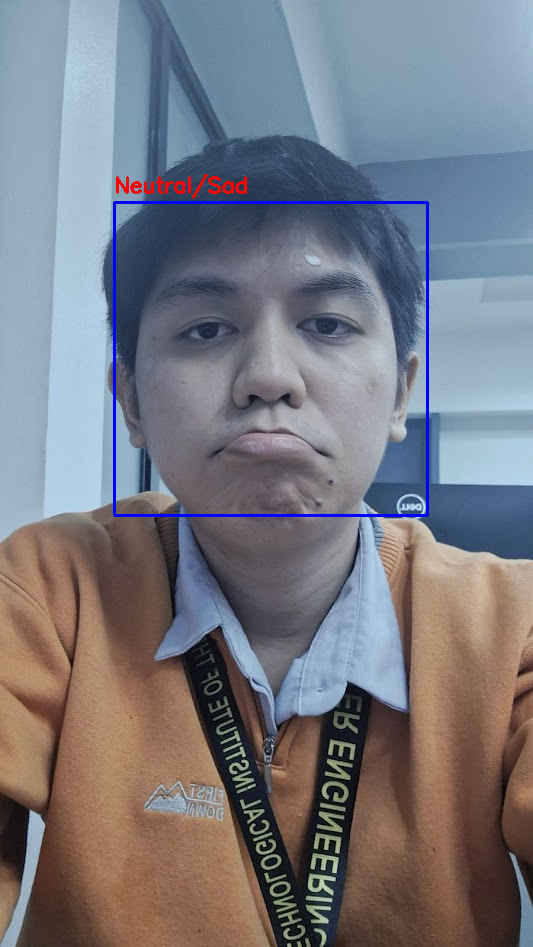

In [39]:
# Technique 3

import cv2
from google.colab.patches import cv2_imshow

picPath = '/content/haretest6(sad).jpeg'
haarPath_face = '/content/haarcascade_frontalface_default(1).xml'
haarPath_smile = '/content/haarcascade_smile(1).xml'

def detect_happy(image_path):
  face_cascade = cv2.CascadeClassifier(haarPath_face)
  smile_cascade = cv2.CascadeClassifier(haarPath_smile)

  img = cv2.imread(image_path)
  if img is None:
      print(f"Error: Unable to load image at {image_path}")
      return

  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


  faces = face_cascade.detectMultiScale(gray, 1.3, 5)

  for (x, y, w, h) in faces:

    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]


    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.7,
        minNeighbors=22,
        minSize=(25, 25),
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    if len(smiles) > 0:
      cv2.putText(img, 'Happy (Smile Detected)', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
      for (sx, sy, sw, sh) in smiles:
          cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 255, 0), 2)
    else:
      cv2.putText(img, 'Neutral/Sad', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

  cv2_imshow(img)


detect_happy(picPath)

---

## Analysis

For the three different techniques you used in face detection, provide an in-depth analysis.

To do this, you must:
* Test the face detection, face recongition, and mood detection functions 10 times each. Only the mood detection will have components for 10 tests for each different technique used.
* Create a table containing the 10 tests (like shown below) for each task.
* Analyze each output by identifying the accuracy and providing your observations.

In [42]:
# Import the module for tabulating the data
from tabulate import tabulate

# Create a list for content of the table
test_results = [
    ["1", "Happy", "Sad", 1],
    ["2", "Happy", "Neutral", 1],
    ["3", "Happy", "Happy", 1]
]

# Create a list for the headers of your table
header = ["Test #", "Expected", "Actual", "Score"]

# display table
print("Task 3A: Mood Detection using XYZ Algorithm")
print(tabulate(test_results, headers=header, tablefmt="grid"))

# Calculate for the accuracy
total = 0
for i in test_results:
    total += i[3]
print("Accuracy: ", round(total/len(test_results)*100,2))

Task 3A: Mood Detection using XYZ Algorithm
+----------+------------+----------+---------+
|   Test # | Expected   | Actual   |   Score |
+==========+============+==========+=========+
|        1 | Happy      | Sad      |       1 |
+----------+------------+----------+---------+
|        2 | Happy      | Neutral  |       1 |
+----------+------------+----------+---------+
|        3 | Happy      | Happy    |       1 |
+----------+------------+----------+---------+
Accuracy:  100.0


---

## Summary and Lessons Learned

In this Midterm exam, We developed a mood detection program using an object-oriented approach that includes face detection, face recognition, and mood detection. We used methods like Haar Cascade and we noticed that each method has different levels of difficulty and accuracy. Through this activity, we realized that detecting emotions is not easy and it requires the right methods and proper testing to get better results.

---

**Proprietary Clause**

Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated or reduced to any electronic medium or machine-readable form, in whole or in part, without prior consent of T.I.P.

Prepared by Engr. RMR